# Interview Prep Corpus Builder

This notebook collects interview-prep articles for machine learning and adjacent engineering roles, cleans the text, and exports a corpus that is safe to use for GraphRAG.

**Outputs**
- `interview_prep_corpus.csv`: audited corpus with quality flags and a `keep_for_graph` column

**What matters here**
- scraping the right pages
- cleaning them without destroying the useful content
- validating that the final rows are actually interview-prep material before any graph extraction starts

## Workflow

1. Search targeted interview-prep queries by role family.
2. Fetch and extract readable article text.
3. Clean and normalize the text.
4. Run quality checks: duplicates, domain mix, relevance, raw-vs-clean samples, suspicious rows.
5. Export only after the corpus looks trustworthy.

In [ ]:
%pip install -q pandas requests beautifulsoup4 trafilatura google-search-results lxml matplotlib seaborn tldextract tqdm python-dotenv


In [1]:
from __future__ import annotations

import os
import re
import time
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
import tldextract
import trafilatura
from bs4 import BeautifulSoup
from serpapi import GoogleSearch
from dotenv import load_dotenv
from IPython.display import Markdown, display
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")
DATA_DIR = Path.cwd()
load_dotenv(DATA_DIR / ".env", override=False)


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Search Configuration

The query set is intentionally interview-focused. We are not scraping job postings, salary pages, or generic career portals. The goal is to collect study guides, topic breakdowns, and role-comparison content that explicitly discusses what candidates should prepare for.

In [2]:
SEARCH_QUERIES = {
    "Machine Learning Engineer": [
        "Machine Learning Engineer interview preparation guide",
        "Machine Learning Engineer interview questions topics",
        "ML system design interview preparation",
    ],
    "AI Engineer": [
        "AI Engineer interview preparation roadmap",
        "Applied AI Engineer interview questions",
    ],
    "Data Scientist": [
        "Data Scientist interview questions topics",
        "data science interview statistics topics",
    ],
    "MLOps Engineer": [
        "MLOps Engineer interview guide",
        "MLOps interview preparation topics",
    ],
    "Data Engineer": [
        "Data Engineer interview preparation topics",
        "data engineering interview guide pipelines spark sql",
    ],
    "NLP Engineer": [
        "NLP Engineer interview preparation",
        "NLP interview topics transformers bert sequence modeling",
    ],
    "Computer Vision Engineer": [
        "Computer Vision Engineer interview topics",
        "computer vision interview preparation cnn detection segmentation",
    ],
}

MAX_RESULTS_PER_QUERY = 8
SERP_API_KEY = os.getenv("SERP_API_KEY") or os.getenv("SERPAPI_API_KEY") or os.getenv("SERPAPI_KEY")
if not SERP_API_KEY:
    raise ValueError("Set SERP_API_KEY, SERPAPI_API_KEY, or SERPAPI_KEY in .env before running the notebook.")
REQUEST_TIMEOUT_SECONDS = 20
REQUEST_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}

INTERVIEW_KEYWORDS = {
    "interview", "prepare", "preparation", "questions", "study", "guide", "roadmap",
    "system design", "coding", "statistics", "machine learning", "sql", "behavioral",
}

BLOCKLIST_DOMAINS = {
    "linkedin.com",
    "indeed.com",
    "glassdoor.com",
    "ziprecruiter.com",
    "monster.com",
}

BLOCKLIST_URL_SNIPPETS = [
    "/jobs",
    "/job/",
    "/careers",
    "/salary",
]

MIN_CLEAN_CHARS = 1200
SOFT_MAX_CLEAN_CHARS = 40000
HARD_MAX_CLEAN_CHARS = 120000
MIN_INTERVIEW_KEYWORD_HITS = 3
MIN_ROWS_FOR_DOMAIN_CAP = 12
MAX_DOMAIN_SHARE_PER_ROLE = 0.45


In [3]:
def normalize_domain(url: str) -> str:
    host = urlparse(url).netloc.lower()
    if host.startswith("www."):
        host = host[4:]
    ext = tldextract.extract(host)
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    return host


def blocked_url(url: str) -> bool:
    domain = normalize_domain(url)
    if domain in BLOCKLIST_DOMAINS:
        return True
    lowered = url.lower()
    return any(snippet in lowered for snippet in BLOCKLIST_URL_SNIPPETS)


def search_web(queries: dict[str, list[str]], max_results_per_query: int = MAX_RESULTS_PER_QUERY) -> pd.DataFrame:
    rows = []
    for role, role_queries in queries.items():
        for query in role_queries:
            params = {
                "engine": "google",
                "q": query,
                "google_domain": "google.com",
                "hl": "en",
                "gl": "us",
                "api_key": SERP_API_KEY,
                "num": max_results_per_query,
            }
            try:
                results = GoogleSearch(params).get_dict()
            except Exception as exc:
                rows.append(
                    {
                        "job_role_hint": role,
                        "query": query,
                        "title": None,
                        "href": None,
                        "source": None,
                        "error": str(exc),
                    }
                )
                continue

            organic = results.get("organic_results", [])
            for rank, item in enumerate(organic[:max_results_per_query], start=1):
                href = item.get("link")
                rows.append(
                    {
                        "job_role_hint": role,
                        "query": query,
                        "search_rank": rank,
                        "title": item.get("title"),
                        "snippet": item.get("snippet"),
                        "href": href,
                        "source": item.get("source"),
                        "blocked_candidate": blocked_url(href) if href else True,
                        "error": None,
                    }
                )

    search_df = pd.DataFrame(rows)
    search_df = (
        search_df.dropna(subset=["href"])
        .drop_duplicates(subset=["job_role_hint", "href"])
        .reset_index(drop=True)
    )
    if search_df.empty:
        raise ValueError("No search results returned from SerpAPI. Check your API key, credits, network access, or query design.")
    return search_df


In [4]:
search_df = search_web(SEARCH_QUERIES)
search_df.head(10)


,job_role_hint,query,search_rank,title,snippet,href,source,blocked_candidate,error
0,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,1,What is your favorite Machine Learning Engineer Interview ...,"In the 2025 MLE interview, stumper questions can come from absolutely anywhere - data science/ML theory, math/statistics, tech stack/lib...",https://www.reddit.com/r/learnmachinelearning/comments/1ifbwx8/what_is_your_favorite_machine_learning_engineer/,Reddit · r/learnmachinelearning,False,None
1,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,2,Introduction to Machine Learning Interviews Book · MLIB,"The book consists of two parts. The first part provides an overview of the machine learning interview process, what types of machine lea...",https://huyenchip.com/ml-interviews-book/,Chip Huyen,False,None
2,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,3,Software / Machine Learning Engineer Interview Prep,"The following is basically a collection of resources that I found useful in my job search, for the various components of the technical i...",https://gist.github.com/siggiorn/5b77e6ffd29237a8d0fe4610218ef894,Gist,False,None
3,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,4,(Opinionated) Guide to ML Engineer Job Hunting,"What to Prepare · Coding: For MLE candidates, coding interviews are like the GRE for Ph. · ML System Design · ML Breadth · ML Domain Kno...",https://www.yuan-meng.com/posts/mle_interviews/,Yuan Meng,False,None
4,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,5,How to Prepare for Machine Learning Engineer Interviews,Important: interact with your interviewer all the time. Ask questions. Go over a few examples before you start coding. I love this list ...,https://www.linkedin.com/pulse/how-prepare-machine-learning-engineer-interviews-leandro-lima-avmse,LinkedIn · Leandro Lima,True,None
5,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,6,Machine Learning Interview Prep Guide (2026),"Get ready for 2026 machine learning interviews with a guide that covers core concepts, coding skills, system design, and modern AI-drive...",https://www.coursera.org/resources/machine-learning-interview-prep-guide,Coursera,False,None
6,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,7,My experience of interview preparation as MLE,"For an MLE (Machine Learning Engineer) position, the main types of interviews are: Leetcode-style coding questions, ML System Design, qu...",https://artgor.medium.com/my-experience-of-interview-preparation-as-mle-fe53627ba33e,Medium · Andrew Lukyanenko,False,None
7,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,8,Complete Guide to Machine Learning Engineering Interviews,This is an ML engineer interview guide that covers core machine learning concepts you should know before going into interviews and what ...,https://www.tryexponent.com/blog/machine-learning-interview-guide,Exponent,False,None
8,Machine Learning Engineer,Machine Learning Engineer interview questions topics,1,[D] Good ML Eng question banks for interviews?,"So questions are things like: ""write a neural net to solve X problem"" or ""implement k-means using numpy"". Given this is the case, I thin...",https://www.reddit.com/r/MachineLearning/comments/1958jbm/d_good_ml_eng_question_banks_for_interviews/,Reddit · r/MachineLearning,False,None
9,Machine Learning Engineer,Machine Learning Engineer interview questions topics,2,65 Machine Learning Interview Questions 2026,1) What's the trade-off between bias and variance? [src] · 2) What is gradient descent? [src] · 3) Explain over- and under-fitting and h...,https://github.com/andrewekhalel/MLQuestions,GitHub,False,None


In [6]:
search_df.to_csv('search.csv')

In [7]:
display(search_df.groupby(["job_role_hint", "blocked_candidate"]).size().rename("rows").reset_index())
print(f"Unique candidate URLs: {search_df['href'].nunique()}")


,job_role_hint,blocked_candidate,rows
0,AI Engineer,False,14
1,AI Engineer,True,2
2,Computer Vision Engineer,False,11
3,Computer Vision Engineer,True,1
4,Data Engineer,False,13
5,Data Engineer,True,2
6,Data Scientist,False,15
7,Data Scientist,True,1
8,MLOps Engineer,False,8
9,MLOps Engineer,True,2


Unique candidate URLs: 109


## Raw Scraping

We keep both a raw extraction and a cleaned extraction. This is deliberate: if cleaning goes too far, the notebook gives you side-by-side evidence before you export anything.

In [9]:
def download_html(url: str, timeout: int = REQUEST_TIMEOUT_SECONDS) -> str | None:
    try:
        response = requests.get(url, headers=REQUEST_HEADERS, timeout=timeout)
        response.raise_for_status()
        if "text/html" not in response.headers.get("Content-Type", ""):
            return None
        return response.text
    except Exception:
        return None


def fallback_extract(html: str) -> str:
    soup = BeautifulSoup(html, "lxml")
    for tag in soup(["script", "style", "noscript", "svg", "form", "footer", "nav", "header"]):
        tag.decompose()
    return soup.get_text(separator="\n")


def extract_article_text(url: str) -> dict:
    html = download_html(url)
    if not html:
        return {"fetch_status": "failed", "raw_text": None, "downloaded_html_chars": 0}

    downloaded_html_chars = len(html)
    extracted = trafilatura.extract(
        html,
        include_comments=False,
        include_tables=True,
        include_links=False,
        deduplicate=True,
        output_format="txt",
    )
    raw_text = extracted or fallback_extract(html)
    return {
        "fetch_status": "ok",
        "raw_text": raw_text,
        "downloaded_html_chars": downloaded_html_chars,
    }


def scrape_candidates(search_frame: pd.DataFrame, sleep_seconds: float = 1.2) -> pd.DataFrame:
    rows = []
    for row in tqdm(search_frame.to_dict(orient="records"), total=len(search_frame), desc="Scraping pages"):
        if row.get("blocked_candidate"):
            rows.append({**row, "fetch_status": "blocked", "raw_text": None, "downloaded_html_chars": 0})
            continue
        extracted = extract_article_text(row["href"])
        rows.append({**row, **extracted})
        time.sleep(sleep_seconds)
    return pd.DataFrame(rows)


raw_df = scrape_candidates(search_df)
raw_df.head(5)


Scraping pages: 100%|██████████| 109/109 [02:37<00:00,  1.45s/it]


,job_role_hint,query,search_rank,title,snippet,href,source,blocked_candidate,error,fetch_status,raw_text,downloaded_html_chars
0,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,1,What is your favorite Machine Learning Engineer Interview ...,"In the 2025 MLE interview, stumper questions can come from absolutely anywhere - data science/ML theory, math/statistics, tech stack/lib...",https://www.reddit.com/r/learnmachinelearning/comments/1ifbwx8/what_is_your_favorite_machine_learning_engineer/,Reddit · r/learnmachinelearning,False,None,ok,\n\n\n\n\n\n\n\n\n\nReddit - Please wait for verification\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n,8454
1,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,2,Introduction to Machine Learning Interviews Book · MLIB,"The book consists of two parts. The first part provides an overview of the machine learning interview process, what types of machine lea...",https://huyenchip.com/ml-interviews-book/,Chip Huyen,False,None,ok,Introduction to Machine Learning Interviews Book\nYou can read the web-friendly version of the book here. You can find the source code o...,52657
2,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,3,Software / Machine Learning Engineer Interview Prep,"The following is basically a collection of resources that I found useful in my job search, for the various components of the technical i...",https://gist.github.com/siggiorn/5b77e6ffd29237a8d0fe4610218ef894,Gist,False,None,ok,"The following is basically a collection of resources that I found useful in my job search, for the various components of the technical i...",136398
3,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,4,(Opinionated) Guide to ML Engineer Job Hunting,"What to Prepare · Coding: For MLE candidates, coding interviews are like the GRE for Ph. · ML System Design · ML Breadth · ML Domain Kno...",https://www.yuan-meng.com/posts/mle_interviews/,Yuan Meng,False,None,ok,"(Opinionated) Guide to ML Engineer Job Hunting\nThe Marriage Analogy\nOver 2 years ago, I wrote a blog post on how to find jobs as a new...",79542
4,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,5,How to Prepare for Machine Learning Engineer Interviews,Important: interact with your interviewer all the time. Ask questions. Go over a few examples before you start coding. I love this list ...,https://www.linkedin.com/pulse/how-prepare-machine-learning-engineer-interviews-leandro-lima-avmse,LinkedIn · Leandro Lima,True,None,blocked,None,0


In [10]:
raw_df.to_csv('raw.csv')

## Cleaning and Heuristic Quality Scoring

The cleaning step strips noise and computes auditable quality signals. Nothing gets silently dropped. Each row gets a reason if it fails the quality gate.

In [11]:
WHITESPACE_RE = re.compile(r"\s+")
NON_ALPHA_RE = re.compile(r"[^A-Za-z]+")
BOILERPLATE_PATTERNS = [
    re.compile(pattern, re.IGNORECASE)
    for pattern in [
        r"cookie policy",
        r"all rights reserved",
        r"sign up for our newsletter",
        r"accept cookies",
        r"subscribe to our channel",
        r"share this article",
    ]
]

ROLE_KEYWORDS = {
    "Machine Learning Engineer": ["machine learning engineer", "ml engineer", "ml system design", "model evaluation", "feature engineering"],
    "AI Engineer": ["ai engineer", "applied ai", "llm engineer", "generative ai", "rag", "agentic"],
    "Data Scientist": ["data scientist", "data science interview", "statistics", "a/b testing", "hypothesis testing"],
    "MLOps Engineer": ["mlops", "machine learning ops", "model deployment", "model monitoring", "feature store", "ml pipeline"],
    "Data Engineer": ["data engineer", "data engineering", "etl", "data pipeline", "spark", "airflow", "data warehouse"],
    "NLP Engineer": ["nlp engineer", "natural language processing", "transformer", "bert", "tokenization"],
    "Computer Vision Engineer": ["computer vision", "vision engineer", "cnn", "opencv", "image segmentation", "object detection"],
}

JOB_POSTING_MARKERS = [
    "job description", "responsibilities", "qualifications", "benefits",
    "salary", "apply now", "equal opportunity", "employment type",
]


def clean_text(raw_text: str | None) -> str:
    if not raw_text:
        return ""
    text = raw_text.replace("\xa0", " ")
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = WHITESPACE_RE.sub(" ", text)
    for pattern in BOILERPLATE_PATTERNS:
        text = pattern.sub(" ", text)
    return text.strip()


def keyword_hits(text: str) -> int:
    lowered = text.lower()
    return sum(keyword in lowered for keyword in INTERVIEW_KEYWORDS)


def infer_content_type(text: str) -> str:
    lowered = text.lower()
    if "system design" in lowered:
        return "system_design_guide"
    if "question" in lowered and "interview" in lowered:
        return "question_bank"
    if "roadmap" in lowered or "prepare" in lowered:
        return "prep_guide"
    if "vs" in lowered or "difference" in lowered:
        return "role_comparison"
    return "general_interview_article"


def refine_role_hint(row: pd.Series) -> str:
    title_and_snippet = f"{row.get('title', '')} {row.get('snippet', '')}".lower()
    combined = f"{title_and_snippet} {row.get('clean_text', '')[:2500]}".lower()
    scores = {}
    for role, keywords in ROLE_KEYWORDS.items():
        title_hits = sum(keyword in title_and_snippet for keyword in keywords)
        body_hits = sum(keyword in combined for keyword in keywords)
        scores[role] = (2 * title_hits) + body_hits
    original_hint = row.get("job_role_hint", "Unknown")
    if original_hint in scores:
        scores[original_hint] += 1
    best_role = max(scores, key=scores.get)
    return best_role if scores[best_role] > 0 else original_hint


def quality_flags(row: pd.Series) -> tuple[bool, list[str]]:
    reasons = []
    clean = row.get("clean_text", "")
    domain = row.get("domain", "")
    hits = keyword_hits(clean)
    if row.get("fetch_status") != "ok":
        reasons.append("fetch_failed")
    if len(clean) < MIN_CLEAN_CHARS:
        reasons.append("too_short")
    if len(clean) > HARD_MAX_CLEAN_CHARS:
        reasons.append("too_long")
    elif len(clean) > SOFT_MAX_CLEAN_CHARS and hits < 6:
        reasons.append("too_long")
    if hits < MIN_INTERVIEW_KEYWORD_HITS:
        reasons.append("weak_interview_signal")
    if domain in BLOCKLIST_DOMAINS:
        reasons.append("blocked_domain")
    alpha_ratio = len(NON_ALPHA_RE.sub("", clean)) / max(len(clean), 1)
    if alpha_ratio < 0.55:
        reasons.append("low_alpha_ratio")
    lowered = clean.lower()
    posting_hits = sum(marker in lowered for marker in JOB_POSTING_MARKERS)
    if posting_hits >= 3 and hits < 5 and "interview" not in lowered:
        reasons.append("looks_like_job_posting")
    keep = not reasons
    return keep, reasons


def apply_cleaning(raw_frame: pd.DataFrame) -> pd.DataFrame:
    df = raw_frame.copy()
    df["domain"] = df["href"].map(normalize_domain)
    df["raw_text"] = df["raw_text"].fillna("")
    df["clean_text"] = df["raw_text"].map(clean_text)
    df["text_length_raw"] = df["raw_text"].str.len()
    df["text_length_clean"] = df["clean_text"].str.len()
    df["keyword_hits"] = df["clean_text"].map(keyword_hits)
    df["content_type"] = df["clean_text"].map(infer_content_type)
    df["job_role_hint"] = df.apply(refine_role_hint, axis=1)
    quality_results = df.apply(quality_flags, axis=1)
    df["keep_for_graph"] = quality_results.map(lambda item: item[0])
    df["drop_reason"] = quality_results.map(lambda item: ";".join(item[1]))
    df["duplicate_clean_text"] = df.duplicated(subset=["clean_text"], keep=False)
    df.loc[df["duplicate_clean_text"], "keep_for_graph"] = False
    df.loc[df["duplicate_clean_text"], "drop_reason"] = df.loc[
        df["duplicate_clean_text"], "drop_reason"
    ].replace("", "duplicate_clean_text")
    return df


corpus_df = apply_cleaning(raw_df)
corpus_df.head(5)


,job_role_hint,query,search_rank,title,snippet,href,source,blocked_candidate,error,fetch_status,...,downloaded_html_chars,domain,clean_text,text_length_raw,text_length_clean,keyword_hits,content_type,keep_for_graph,drop_reason,duplicate_clean_text
0,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,1,What is your favorite Machine Learning Engineer Interview ...,"In the 2025 MLE interview, stumper questions can come from absolutely anywhere - data science/ML theory, math/statistics, tech stack/lib...",https://www.reddit.com/r/learnmachinelearning/comments/1ifbwx8/what_is_your_favorite_machine_learning_engineer/,Reddit · r/learnmachinelearning,False,None,ok,...,8454,reddit.com,Reddit - Please wait for verification,73,37,0,general_interview_article,False,too_short;weak_interview_signal,True
1,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,2,Introduction to Machine Learning Interviews Book · MLIB,"The book consists of two parts. The first part provides an overview of the machine learning interview process, what types of machine lea...",https://huyenchip.com/ml-interviews-book/,Chip Huyen,False,None,ok,...,52657,huyenchip.com,Introduction to Machine Learning Interviews Book You can read the web-friendly version of the book here. You can find the source code on...,3764,3764,4,question_bank,True,,False
2,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,3,Software / Machine Learning Engineer Interview Prep,"The following is basically a collection of resources that I found useful in my job search, for the various components of the technical i...",https://gist.github.com/siggiorn/5b77e6ffd29237a8d0fe4610218ef894,Gist,False,None,ok,...,136398,github.com,"The following is basically a collection of resources that I found useful in my job search, for the various components of the technical i...",12268,12268,10,system_design_guide,True,,False
3,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,4,(Opinionated) Guide to ML Engineer Job Hunting,"What to Prepare · Coding: For MLE candidates, coding interviews are like the GRE for Ph. · ML System Design · ML Breadth · ML Domain Kno...",https://www.yuan-meng.com/posts/mle_interviews/,Yuan Meng,False,None,ok,...,79542,yuan-meng.com,"(Opinionated) Guide to ML Engineer Job Hunting The Marriage Analogy Over 2 years ago, I wrote a blog post on how to find jobs as a new g...",33687,33687,11,system_design_guide,True,,False
4,Machine Learning Engineer,Machine Learning Engineer interview preparation guide,5,How to Prepare for Machine Learning Engineer Interviews,Important: interact with your interviewer all the time. Ask questions. Go over a few examples before you start coding. I love this list ...,https://www.linkedin.com/pulse/how-prepare-machine-learning-engineer-interviews-leandro-lima-avmse,LinkedIn · Leandro Lima,True,None,blocked,...,0,linkedin.com,,0,0,0,general_interview_article,False,fetch_failed;too_short;weak_interview_signal;blocked_domain;low_alpha_ratio,True


## QA Checkpoint 1: Coverage and Filtering

This section shows how much content was collected, what got dropped, and whether the domain mix looks healthy.

In [12]:
summary = {
    "candidate_urls": int(search_df["href"].nunique()),
    "scraped_rows": int(len(raw_df)),
    "kept_rows": int(corpus_df["keep_for_graph"].sum()),
    "dropped_rows": int((~corpus_df["keep_for_graph"]).sum()),
    "unique_domains": int(corpus_df["domain"].nunique()),
}
summary


{'candidate_urls': 109,
 'scraped_rows': 109,
 'kept_rows': 56,
 'dropped_rows': 53,
 'unique_domains': 41}

In [13]:
domain_counts = corpus_df.groupby(["domain", "keep_for_graph"]).size().rename("rows").reset_index()
display(domain_counts.sort_values(["rows", "domain"], ascending=[False, True]).head(20))

display(corpus_df.groupby(["job_role_hint", "keep_for_graph"]).size().rename("rows").reset_index())


,domain,keep_for_graph,rows
21,medium.com,False,14
29,reddit.com,False,11
12,github.com,True,10
18,linkedin.com,False,9
4,coursera.org,True,6
6,datacamp.com,False,4
10,geeksforgeeks.org,True,4
0,365datascience.com,True,3
2,analyticsvidhya.com,True,3
9,geeksforgeeks.org,False,3


,job_role_hint,keep_for_graph,rows
0,AI Engineer,False,6
1,AI Engineer,True,7
2,Computer Vision Engineer,False,4
3,Computer Vision Engineer,True,8
4,Data Engineer,False,9
5,Data Engineer,True,6
6,Data Scientist,False,8
7,Data Scientist,True,8
8,MLOps Engineer,False,7
9,MLOps Engineer,True,5


## QA Checkpoint 2: Length and Relevance

These charts help catch pages that are too short, overly noisy, or dominated by non-article text.

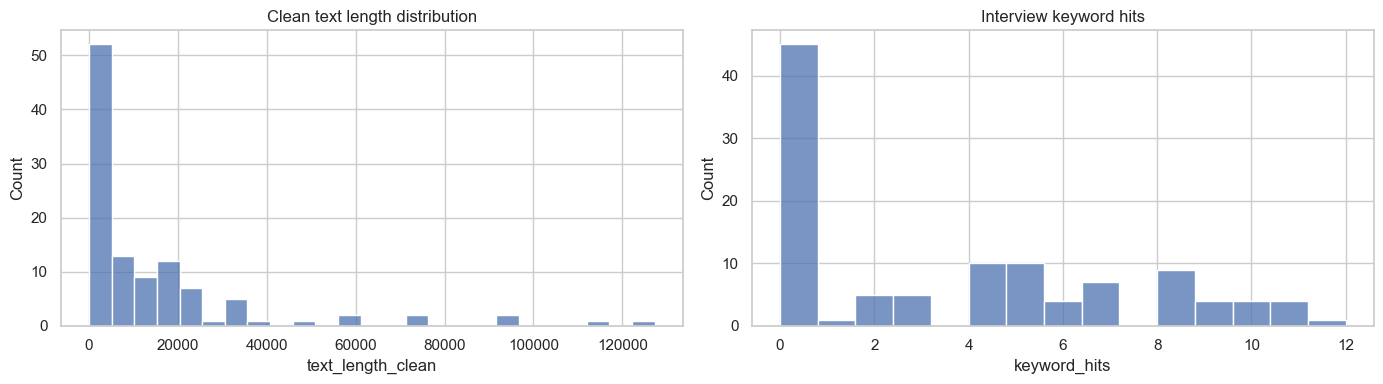

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(corpus_df["text_length_clean"], bins=25, ax=axes[0])
axes[0].set_title("Clean text length distribution")
sns.histplot(corpus_df["keyword_hits"], bins=15, ax=axes[1])
axes[1].set_title("Interview keyword hits")
plt.tight_layout()


## QA Checkpoint 3: Raw vs Clean Inspection

Use this to manually verify that the cleaning step removes junk but keeps interview-relevant content.

In [16]:
def preview_row(frame: pd.DataFrame, index: int) -> None:
    row = frame.iloc[index]
    display(Markdown(f"### {row['title']}"))
    print(f"Role hint: {row['job_role_hint']}")
    print(f"Domain: {row['domain']}")
    print(f"Keep for graph: {row['keep_for_graph']}")
    print(f"Drop reason: {row['drop_reason']}")
    print("\nRAW TEXT PREVIEW\n")
    print((row["raw_text"] or "")[:2000])
    print("\nCLEAN TEXT PREVIEW\n")
    print((row["clean_text"] or "")[:2000])


preview_row(corpus_df, 0)


### What is your favorite Machine Learning Engineer Interview ...

Role hint: Machine Learning Engineer
Domain: reddit.com
Keep for graph: False
Drop reason: too_short;weak_interview_signal

RAW TEXT PREVIEW











Reddit - Please wait for verification



























CLEAN TEXT PREVIEW

Reddit - Please wait for verification


In [17]:
review_sample = corpus_df.sample(min(8, len(corpus_df)), random_state=42)[
    ["job_role_hint", "title", "domain", "keep_for_graph", "drop_reason", "content_type", "text_length_clean"]
]
review_sample


,job_role_hint,title,domain,keep_for_graph,drop_reason,content_type,text_length_clean
78,Data Engineer,100 Spark Interview Questions for Data Engineer,dev.to,True,,question_bank,17842
10,Machine Learning Engineer,Machine Learning Interview Questions and Answers,geeksforgeeks.org,True,,question_bank,92968
4,Machine Learning Engineer,How to Prepare for Machine Learning Engineer Interviews,linkedin.com,False,fetch_failed;too_short;weak_interview_signal;blocked_domain;low_alpha_ratio,general_interview_article,0
84,NLP Engineer,50 Core NLP Interview Questions in 2026,github.com,True,,question_bank,34207
64,MLOps Engineer,Learn 100 MLOps interview questions and answers,linkedin.com,False,fetch_failed;too_short;weak_interview_signal;blocked_domain;low_alpha_ratio,general_interview_article,0
68,Data Engineer,Data Engineering Study Guide - Outline (Make A Copy :),linkedin.com,False,fetch_failed;too_short;weak_interview_signal;blocked_domain;low_alpha_ratio,general_interview_article,0
30,AI Engineer,How to pass a technical interview for an AI role,substack.com,True,,question_bank,9091
45,Data Scientist,Data Science Interview Questions and Answers,geeksforgeeks.org,True,,question_bank,76316


## QA Checkpoint 4: Duplicate and Source Balance Review

If one domain overwhelms the corpus, the graph will inherit that bias. This is a simple cap you can apply before export if needed.

In [18]:
domain_role_counts = (
    corpus_df.loc[corpus_df["keep_for_graph"]]
    .groupby(["job_role_hint", "domain"])
    .size()
    .rename("rows")
    .reset_index()
)
display(domain_role_counts.sort_values(["job_role_hint", "rows"], ascending=[True, False]).head(30))

role_totals = corpus_df.loc[corpus_df["keep_for_graph"]].groupby("job_role_hint").size().rename("role_total").reset_index()
domain_role_counts = domain_role_counts.merge(role_totals, on="job_role_hint", how="left")
domain_role_counts["share"] = domain_role_counts["rows"] / domain_role_counts["role_total"].clip(lower=1)

over_cap = domain_role_counts.loc[
    (domain_role_counts["role_total"] >= MIN_ROWS_FOR_DOMAIN_CAP)
    & (domain_role_counts["share"] > MAX_DOMAIN_SHARE_PER_ROLE),
    ["job_role_hint", "domain"]
]
if not over_cap.empty:
    mask = corpus_df.set_index(["job_role_hint", "domain"]).index.isin(
        over_cap.set_index(["job_role_hint", "domain"]).index
    )
    corpus_df.loc[mask & corpus_df["keep_for_graph"], "keep_for_graph"] = False
    corpus_df.loc[mask & corpus_df["drop_reason"].fillna("").eq(""), "drop_reason"] = "domain_overrepresented"

corpus_df["drop_reason"].value_counts().head(20)


,job_role_hint,domain,rows
1,AI Engineer,github.com,2
0,AI Engineer,365datascience.com,1
2,AI Engineer,moderndescartes.com,1
3,AI Engineer,substack.com,1
4,AI Engineer,turing.com,1
5,AI Engineer,usebraintrust.com,1
6,Computer Vision Engineer,365datascience.com,1
7,Computer Vision Engineer,analyticsvidhya.com,1
8,Computer Vision Engineer,coursera.org,1
9,Computer Vision Engineer,github.com,1


drop_reason
                                                                               56
fetch_failed;too_short;weak_interview_signal;low_alpha_ratio                   23
too_short;weak_interview_signal                                                14
fetch_failed;too_short;weak_interview_signal;blocked_domain;low_alpha_ratio    10
weak_interview_signal                                                           3
too_short                                                                       1
too_long                                                                        1
too_long;weak_interview_signal                                                  1
Name: count, dtype: int64

## Final Export

Do not skip the QA cells above. This export is intentionally last so you only write the corpus after checking that the kept rows are actually useful.

In [19]:
final_columns = [
    "job_role_hint", "query", "title", "snippet", "source", "href", "domain",
    "raw_text", "clean_text", "text_length_raw", "text_length_clean", "keyword_hits",
    "content_type", "keep_for_graph", "drop_reason"
]

export_df = corpus_df[final_columns].sort_values(
    ["keep_for_graph", "job_role_hint", "domain"],
    ascending=[False, True, True],
).reset_index(drop=True)
export_path = DATA_DIR / "interview_prep_corpus.csv"
export_df.to_csv(export_path, index=False)

print(f"Saved audited corpus to: {export_path}")
print(f"Rows kept for graph: {int(export_df['keep_for_graph'].sum())}")
print(f"Rows excluded: {int((~export_df['keep_for_graph']).sum())}")
export_df.head(10)


Saved audited corpus to: \\wsl.localhost\Ubuntu\home\shubh\graphRAG\interview_prep_corpus.csv
Rows kept for graph: 56
Rows excluded: 53


,job_role_hint,query,title,snippet,source,href,domain,raw_text,clean_text,text_length_raw,text_length_clean,keyword_hits,content_type,keep_for_graph,drop_reason
0,AI Engineer,Applied AI Engineer interview questions,Common AI Engineer Interview Questions & Answers (2025),"Question 6: What is transfer learning, and how have you applied it in your projects? Question 7: How do you optimize hyperparameters in ...",365 Data Science,https://365datascience.com/career-advice/job-interview-tips/ai-engineer-interview-questions/,365datascience.com,It seems like every day we hear about some new AI development—whether it's an update to popular chatbots like ChatGPT or a robot that ca...,It seems like every day we hear about some new AI development—whether it's an update to popular chatbots like ChatGPT or a robot that ca...,20671,20671,8,question_bank,True,
1,AI Engineer,AI Engineer interview preparation roadmap,alexeygrigorev/ai-engineering-field-guide,"Interview Preparation · Interview process - common patterns, step counts, time estimates, AI use in hiring, key takeaways · Interview qu...",GitHub,https://github.com/alexeygrigorev/ai-engineering-field-guide,github.com,"Data-driven field guide to AI engineering roles, skills, and interviews.\nEverything here is based on real data: 2,445 actual job descri...","Data-driven field guide to AI engineering roles, skills, and interviews. Everything here is based on real data: 2,445 actual job descrip...",4110,4110,7,system_design_guide,True,
2,AI Engineer,Applied AI Engineer interview questions,amitshekhariitbhu/ai-engineering-interview-questions ...,"What is prompt engineering, and why is it critical for AI applications? Explain zero-shot, one-shot, and few-shot prompting with examples.",GitHub,https://github.com/amitshekhariitbhu/ai-engineering-interview-questions,github.com,AI Engineering Interview Questions and Answers - Your Cheat Sheet For AI Engineering Interviews\nThese interview questions and answers a...,AI Engineering Interview Questions and Answers - Your Cheat Sheet For AI Engineering Interviews These interview questions and answers ar...,35049,35049,8,system_design_guide,True,
3,AI Engineer,AI Engineer interview preparation roadmap,Interviewing for ML/AI Engineers,"For staff+ candidates, I would do a coding interview, 2 data modeling interviews, 1 system design interview, 1 ML system design intervie...",Brian Kihoon Lee,https://www.moderndescartes.com/essays/ml_eng_interviewing/,moderndescartes.com,"Interviewing for ML/AI Engineers\n2025-12-22\nTagged: software engineering, strategy, machine learning, popular ⭐️\nIn my recent job sea...","Interviewing for ML/AI Engineers 2025-12-22 Tagged: software engineering, strategy, machine learning, popular ⭐️ In my recent job search...",15473,15473,8,system_design_guide,True,
4,AI Engineer,AI Engineer interview preparation roadmap,How to pass a technical interview for an AI role,"Think of the topic you need to explore as a map. A map you need to learn the best you can in a short amount of time. In my case, I was l...",Substack · Pau Labarta Bajo's Newsletter,https://paulabartabajo.substack.com/p/how-to-pass-a-technical-interview,substack.com,How to pass a technical interview for an AI role\nHere's my story\nTwo weeks ago I started my first round of technical interviews in a l...,How to pass a technical interview for an AI role Here's my story Two weeks ago I started my first round of technical interviews in a loo...,9091,9091,5,question_bank,True,
5,AI Engineer,Applied AI Engineer interview questions,100 AI interview questions and answers for 2025,1. Explain Artificial Intelligence and give its applications. · 2. How are machine learning and AI related? · 3. What is Deep Learning b...,Turing,https://www.turing.com/interview-questions/artificial-intelligence,turing.com,AI\nBasic Interview Q&A\n1. Explain Artificial Intelligence and give its applications.\nArtificial Intelligence (AI) is a field of Compu...,AI Basic Interview Q&A 1. Explain Art